<div style="text-align: center; font-weight: bold; font-size: 150%">Projet 5 - LRP(Layer-wise Relevance Propagation) applied onto a Fully Connected (FC) Neural Network</div><br>
<div style="text-align: center; font-size: 100%">Yayrale AKIBODE</div><br>
<div style="text-align: center; font-size: 100%">Professeur: Stéphane CHRETIEN</div><br>
<div style="text-align: center; font-size: 100%">M2 MALIA - Université Lumière Lyon 2</div>

Ce travail se base sur le notebook [ici](https://colab.research.google.com/drive/1W7E0NYfiDP26MTVcVu34cd2luZgskTd7?usp=sharing).

**Installation et importation des packages**

In [66]:
################################################################################
# [0.] Installation of the necessary packages ==================================
################################################################################

!pip3 install scipy
!pip3 install matplotlib

from IPython.display import Image
from IPython.display import Math
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import unittest

You should consider upgrading via the '/Users/yayraleakibode/Documents/Master_MALIA/DataSciencePortfolio/xai/venv_py_3.9/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/Users/yayraleakibode/Documents/Master_MALIA/DataSciencePortfolio/xai/venv_py_3.9/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/Users/yayraleakibode/Documents/Master_MALIA/DataSciencePortfolio/xai/venv_py_3.9/bin/python3 -m pip install --upgrade pip' command.
You should consider upgrading via the '/Users/yayraleakibode/Documents/Master_MALIA/DataSciencePortfolio/xai/venv_py_3.9/bin/python3 -m pip install --upgrade pip' command.


<div style="text-align: center; font-weight: bold; font-size: 125%">1. LRP: Layer-wise Relevance Propagation</div><br>

La méthode LRP explique une prédiction en redistribuant son score jusqu’aux entrées pour identifier ce qui a réellement compté. Cette méthode cherche à déterminer de façon réelle l'influence des entrées sur la sortie sans changer le modèle. Les scores attribués aux entrées sont appelés relevances. À la fin de le redistribution, on doit avoir: 

$$
\sum \text{relevances} = \text{score du modèle}
$$

On parle de propriété de conservativité.

<div style="text-align: center; font-weight: bold; font-size: 125%">2. Réseau à étudier</div><br>

Le réseau étudié dans ce notebook, est un réseau fully connected. Il comporte trois couches: 

- Couche d'entrée $x_i$ : 3 neurones et une fonction d'activation ReLU
- Couche cachée $x_j$ : 5 neurones et une fonction d'activation linéaire
- Couche de sortie $x_k$ : 1 neurone

$x_j = max(0, \sum_i x_i w_{ij} + b_j)$. $w_{ij}\:$ sont les poids entre la $i$-ème et la $j$-ième couche et $b_j$ le biais.

$x_k = \sum_j w_{jk} x_j + b_k$. $w_{jk}\:$ sont les poids entre la $j$-ème et la $k$-ième couche et $b_k$ le biais.

Dans le notebook original les $w_{jk}$ sont tous égaux à 1. Pour cette experimétation, ils seront aléatoires.

**Architecture du réseau FC**

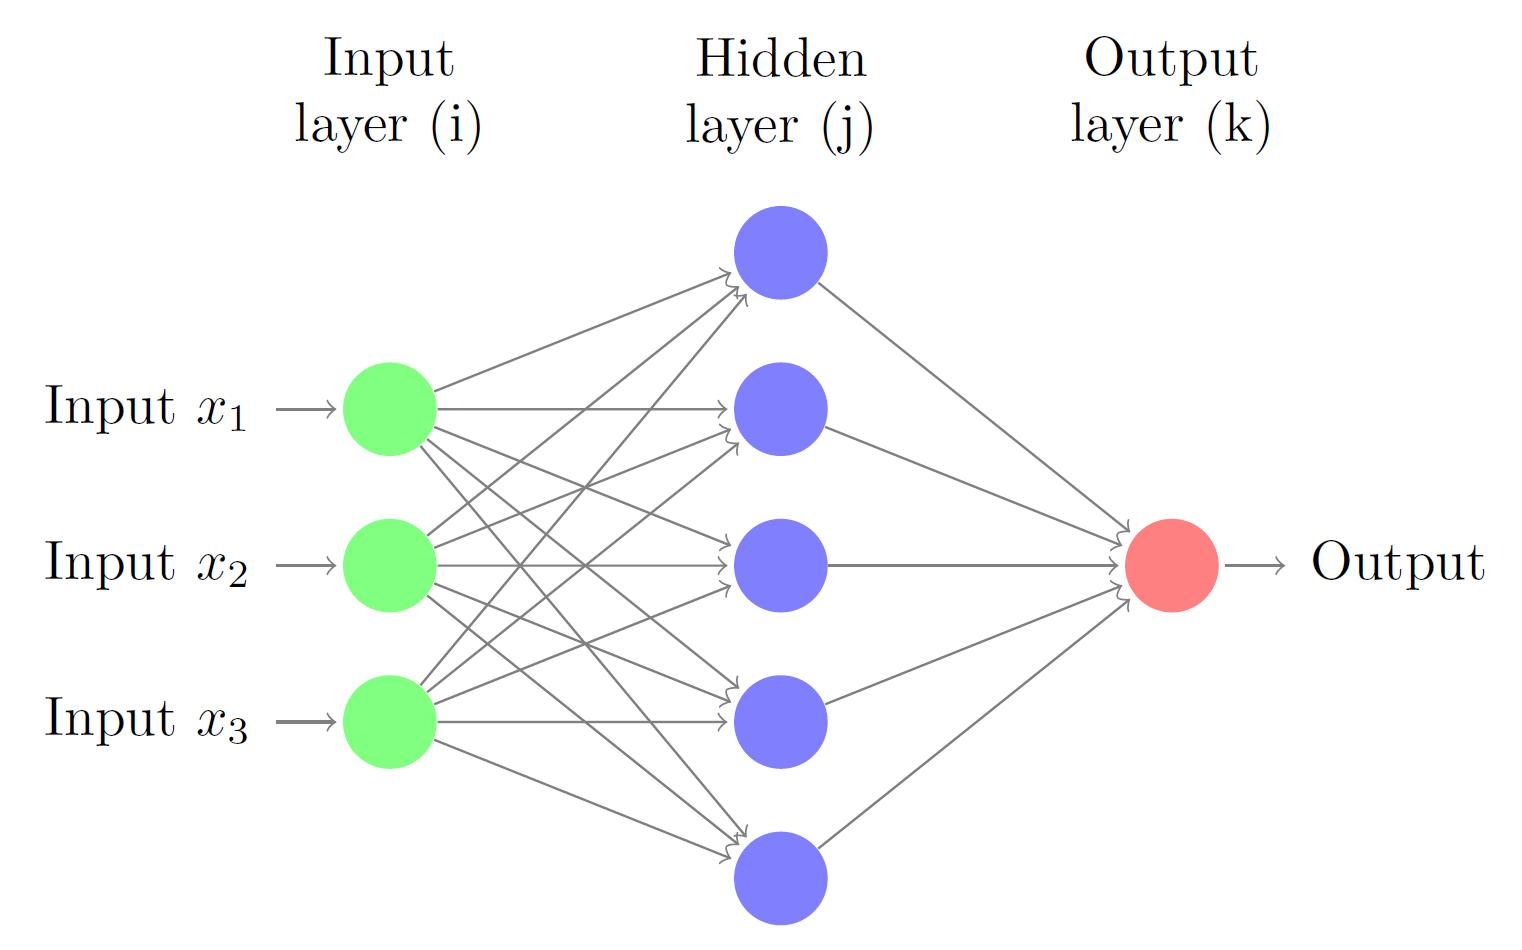

In [52]:
Image("images/FC_Neural_Network_A.png")

**Zoom sur la couche cachée**

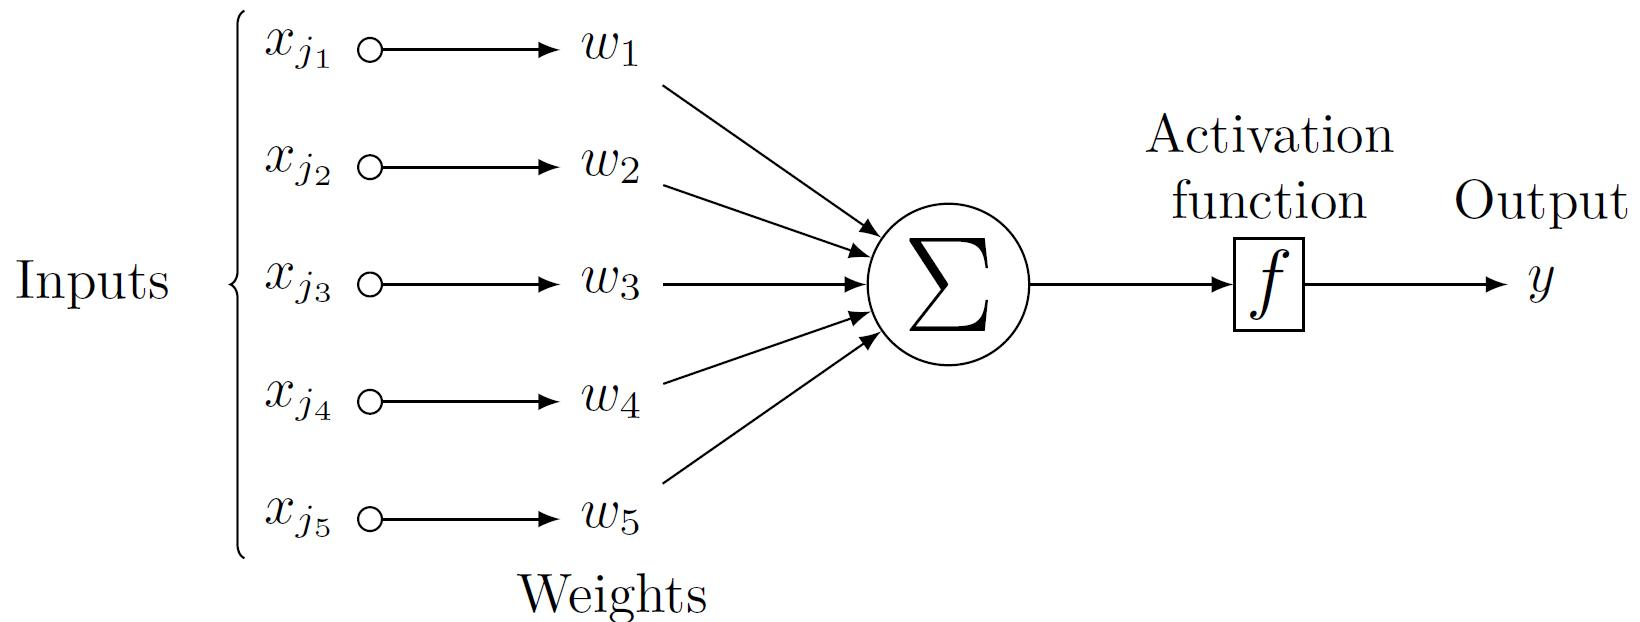

In [53]:
Image("images/FC_Neural_Network_B.jpeg")

**Expressions des relevances**

In [ ]:
################################################################################
# Mathematical equations for the computation of relevances (R) =================
# in the output (k), hidden (j) and input (i) layer. ===========================
################################################################################

Math(r"""
x_j = \max(0, \sum_i x_i w_{ij} + b_j)
\\
x_k = \sum_j x_j w_{jk} + b_k
\\
R_k = x_k
""")

<IPython.core.display.Math object>

In [55]:
# The relevance of each neuron j in layer (j) is R_j. --------------------------
# This can be deduced from the equation that computes x_j ----------------------
# and by the observation that the root point (x_tilde) equals to zero. ---------

Math(r"""
R_j = \sum_k 
\frac{x_j w_{jk}}
{\sum_{j'} x_{j'} w_{j'k}}
\, R_k
""")


<IPython.core.display.Math object>

In [56]:
# The relevance of each neuron i in layer (i), which is practically the input --
# is R_i. The mathematical equations behind this computation -------------------

Math(r'R_i = \sum_j \frac{w_{ij}^2}{\sum_{i^{\prime}} w_{i^{\prime}j}^2} R_j')

<IPython.core.display.Math object>

<div style="text-align: center; font-weight: bold; font-size: 125%">3. Application du LRP sur le réseau </div><br>

Les biais n'interviennent pas dans le calcul des relevances donc ils sont mis à 0.

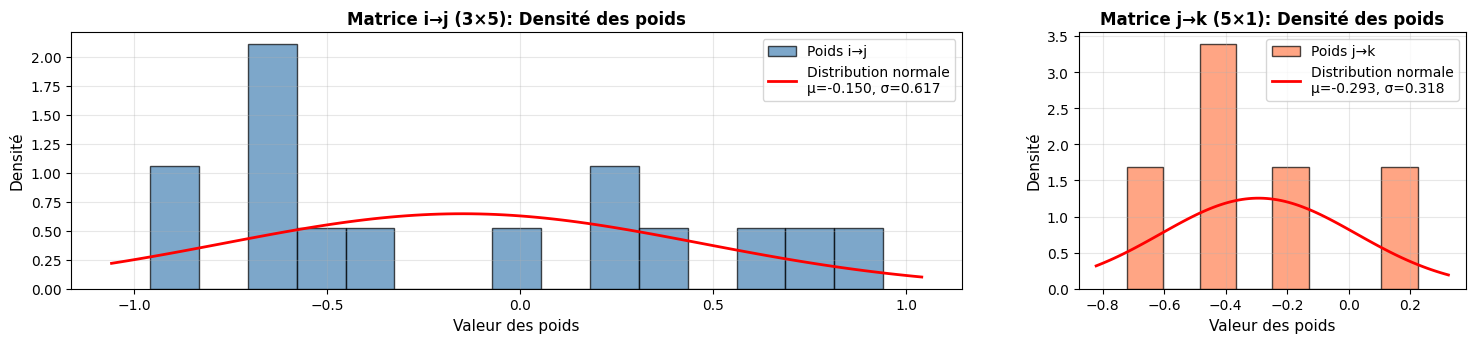

In [ ]:
################################################################################
# [1.] Define input, weights ===================================================
#      and see their distribution with a histogram =============================
################################################################################

# i: input layer, j: hidden layer, k: output layer

# 1.1. Generate random values --------------------------------------------------
# Set random seed for reproducibility
np.random.seed(42)

# Generate random inputs (3 neurons)
x_i_dict = {f'x_{i+1}': np.random.uniform(-10, 10) for i in range(3)}

# Generate random weights from input to hidden layer (3 inputs x 5 hidden neurons)
w_j_1_dict = {f'w_i{i+1}_j1': np.random.uniform(-1, 1) for i in range(3)}
w_j_2_dict = {f'w_i{i+1}_j2': np.random.uniform(-1, 1) for i in range(3)}
w_j_3_dict = {f'w_i{i+1}_j3': np.random.uniform(-1, 1) for i in range(3)}
w_j_4_dict = {f'w_i{i+1}_j4': np.random.uniform(-1, 1) for i in range(3)}
w_j_5_dict = {f'w_i{i+1}_j5': np.random.uniform(-1, 1) for i in range(3)}

# Generate random weights from hidden to output layer (5 hidden x 1 output)
w_k_dict = {f'w_j{i+1}_k1': np.random.uniform(-1, 1) for i in range(5)}

# Tableau des poids i -> j
weights_i_to_j = np.array([
    [w_j_1_dict['w_i1_j1'], w_j_2_dict['w_i1_j2'], w_j_3_dict['w_i1_j3'], w_j_4_dict['w_i1_j4'], w_j_5_dict['w_i1_j5']],
    [w_j_1_dict['w_i2_j1'], w_j_2_dict['w_i2_j2'], w_j_3_dict['w_i2_j3'], w_j_4_dict['w_i2_j4'], w_j_5_dict['w_i2_j5']],
    [w_j_1_dict['w_i3_j1'], w_j_2_dict['w_i3_j2'], w_j_3_dict['w_i3_j3'], w_j_4_dict['w_i3_j4'], w_j_5_dict['w_i3_j5']]
])

# Tableau des poids j -> k
weights_j_to_k = np.array([
    [w_k_dict['w_j1_k1']],
    [w_k_dict['w_j2_k1']],
    [w_k_dict['w_j3_k1']],
    [w_k_dict['w_j4_k1']],
    [w_k_dict['w_j5_k1']]
])

# Aplatir les matrices pour avoir tous les poids
all_weights_i_to_j = weights_i_to_j.flatten()
all_weights_j_to_k = weights_j_to_k.flatten()
all_weights = np.concatenate([all_weights_i_to_j, all_weights_j_to_k])

# Créer une figure avec plusieurs sous-graphiques pour l'étude des densités
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1.2 Histogramme et densité de la matrice i -> j
ax1 = fig.add_subplot(gs[0, :2])
ax1.hist(all_weights_i_to_j, bins=15, density=True, alpha=0.7, color='steelblue', edgecolor='black', label='Poids i→j')
mu_ij, std_ij = all_weights_i_to_j.mean(), all_weights_i_to_j.std()
x_range = np.linspace(all_weights_i_to_j.min() - 0.1, all_weights_i_to_j.max() + 0.1, 100)
ax1.plot(x_range, stats.norm.pdf(x_range, mu_ij, std_ij), 'r-', linewidth=2, label=f'Distribution normale\nμ={mu_ij:.3f}, σ={std_ij:.3f}')
ax1.set_xlabel('Valeur des poids', fontsize=11)
ax1.set_ylabel('Densité', fontsize=11)
ax1.set_title('Matrice i→j (3×5): Densité des poids', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 1.3 Histogramme et densité de la matrice j -> k
ax2 = fig.add_subplot(gs[0, 2])
ax2.hist(all_weights_j_to_k, bins=8, density=True, alpha=0.7, color='coral', edgecolor='black', label='Poids j→k')
mu_jk, std_jk = all_weights_j_to_k.mean(), all_weights_j_to_k.std()
x_range_jk = np.linspace(all_weights_j_to_k.min() - 0.1, all_weights_j_to_k.max() + 0.1, 100)
ax2.plot(x_range_jk, stats.norm.pdf(x_range_jk, mu_jk, std_jk), 'r-', linewidth=2, label=f'Distribution normale\nμ={mu_jk:.3f}, σ={std_jk:.3f}')
ax2.set_xlabel('Valeur des poids', fontsize=11)
ax2.set_ylabel('Densité', fontsize=11)
ax2.set_title('Matrice j→k (5×1): Densité des poids', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

In [58]:
################################################################################
# [2.] Compute equations of feedforward pass ===================================
# Apply those equations to compute the output of the network ===================
################################################################################
sum_j1 = x_i_dict['x_1'] * w_j_1_dict['w_i1_j1'] + \
         x_i_dict['x_2'] * w_j_1_dict['w_i2_j1'] + \
         x_i_dict['x_3'] * w_j_1_dict['w_i3_j1']

sum_j2 = x_i_dict['x_1'] * w_j_2_dict['w_i1_j2'] + \
         x_i_dict['x_2'] * w_j_2_dict['w_i2_j2'] + \
         x_i_dict['x_3'] * w_j_2_dict['w_i3_j2']

sum_j3 = x_i_dict['x_1'] * w_j_3_dict['w_i1_j3'] + \
         x_i_dict['x_2'] * w_j_3_dict['w_i2_j3'] + \
         x_i_dict['x_3'] * w_j_3_dict['w_i3_j3']

sum_j4 = x_i_dict['x_1'] * w_j_4_dict['w_i1_j4'] + \
         x_i_dict['x_2'] * w_j_4_dict['w_i2_j4'] + \
         x_i_dict['x_3'] * w_j_4_dict['w_i3_j4']

sum_j5 = x_i_dict['x_1'] * w_j_5_dict['w_i1_j5'] + \
         x_i_dict['x_2'] * w_j_5_dict['w_i2_j5'] + \
         x_i_dict['x_3'] * w_j_5_dict['w_i3_j5']

# Apply ReLU -------------------------------------------------------------------
val_j1 = max(0, sum_j1)
val_j2 = max(0, sum_j2)
val_j3 = max(0, sum_j3)
val_j4 = max(0, sum_j4)
val_j5 = max(0, sum_j5)

# Compute the output of the NN -------------------------------------------------
val_k1 = val_j1 * w_k_dict['w_j1_k1'] + \
         val_j2 * w_k_dict['w_j2_k1'] + \
         val_j3 * w_k_dict['w_j3_k1'] + \
         val_j4 * w_k_dict['w_j4_k1'] + \
         val_j5 * w_k_dict['w_j5_k1']
print(f"Output value of the network: {val_k1}")


Output value of the network: -4.074233062079888


In [59]:
################################################################################
# [3.] Compute the relevances of each neuron in all layers =====================
# The relevances computations follow the mathematical formulas defined above. ==
################################################################################

################################################################################
# [3.1] Compute relevance of output layer (k) ==================================
################################################################################
R_k = val_k1

print(f"Relevances of neurons of k layer: {R_k}")

################################################################################
# [3.2] Compute relevance of every one of the 5 neurons of the layer (j) =======
################################################################################

# Calculate the denominator (sum of all x_j * w_jk)
denominator = val_j1 * w_k_dict['w_j1_k1'] + \
              val_j2 * w_k_dict['w_j2_k1'] + \
              val_j3 * w_k_dict['w_j3_k1'] + \
              val_j4 * w_k_dict['w_j4_k1'] + \
              val_j5 * w_k_dict['w_j5_k1']

# Calculate relevances for each neuron in layer j
R_j1 = (val_j1 * w_k_dict['w_j1_k1']) / denominator * R_k 
R_j2 = (val_j2 * w_k_dict['w_j2_k1']) / denominator * R_k 
R_j3 = (val_j3 * w_k_dict['w_j3_k1']) / denominator * R_k 
R_j4 = (val_j4 * w_k_dict['w_j4_k1']) / denominator * R_k 
R_j5 = (val_j5 * w_k_dict['w_j5_k1']) / denominator * R_k 

print(f"Relevances of neurons of j layer: {R_j1}, {R_j2}, {R_j3}, {R_j4}, {R_j5}")

################################################################################
# [3.3] Compute relevance of every one of the 3 neurons of the layer (i) =======
################################################################################
sum_j1_power = w_j_1_dict['w_i1_j1'] ** 2 + \
               w_j_1_dict['w_i2_j1'] ** 2 + \
               w_j_1_dict['w_i3_j1'] ** 2

sum_j2_power = w_j_2_dict['w_i1_j2'] ** 2 + \
               w_j_2_dict['w_i2_j2'] ** 2 + \
               w_j_2_dict['w_i3_j2'] ** 2

sum_j3_power = w_j_3_dict['w_i1_j3'] ** 2 + \
               w_j_3_dict['w_i2_j3'] ** 2 + \
               w_j_3_dict['w_i3_j3'] ** 2

sum_j4_power = w_j_4_dict['w_i1_j4'] ** 2 + \
               w_j_4_dict['w_i2_j4'] ** 2 + \
               w_j_4_dict['w_i3_j4'] ** 2

sum_j5_power = w_j_5_dict['w_i1_j5'] ** 2 + \
               w_j_5_dict['w_i2_j5'] ** 2 + \
               w_j_5_dict['w_i3_j5'] ** 2

R_i1 = ((w_j_1_dict['w_i1_j1'] ** 2) / sum_j1_power) * R_j1 + \
       ((w_j_2_dict['w_i1_j2'] ** 2) / sum_j2_power) * R_j2 + \
       ((w_j_3_dict['w_i1_j3'] ** 2) / sum_j3_power) * R_j3 + \
       ((w_j_4_dict['w_i1_j4'] ** 2) / sum_j4_power) * R_j4 + \
       ((w_j_5_dict['w_i1_j5'] ** 2) / sum_j5_power) * R_j5

R_i2 = ((w_j_1_dict['w_i2_j1'] ** 2) / sum_j1_power) * R_j1 + \
       ((w_j_2_dict['w_i2_j2'] ** 2) / sum_j2_power) * R_j2 + \
       ((w_j_3_dict['w_i2_j3'] ** 2) / sum_j3_power) * R_j3 + \
       ((w_j_4_dict['w_i2_j4'] ** 2) / sum_j4_power) * R_j4 + \
       ((w_j_5_dict['w_i2_j5'] ** 2) / sum_j5_power) * R_j5

R_i3 = ((w_j_1_dict['w_i3_j1'] ** 2) / sum_j1_power) * R_j1 + \
       ((w_j_2_dict['w_i3_j2'] ** 2) / sum_j2_power) * R_j2 + \
       ((w_j_3_dict['w_i3_j3'] ** 2) / sum_j3_power) * R_j3 + \
       ((w_j_4_dict['w_i3_j4'] ** 2) / sum_j4_power) * R_j4 + \
       ((w_j_5_dict['w_i3_j5'] ** 2) / sum_j5_power) * R_j5


print(f"Relevances of neurons of i layer: {R_i1}, {R_i2}, {R_i3}")


Relevances of neurons of k layer: -4.074233062079888
Relevances of neurons of j layer: -0.0, -4.074233062079888, 0.0, -0.0, -0.0
Relevances of neurons of i layer: -2.3429298455996284, -1.608641131096119, -0.12266208538414121


In [60]:
################################################################################
# Conservativity properties =====================================
# The sum of relevances of all neurons in layer (i) ============================
# equals the sum of relevances of all neurons in layer (j) =====================
# equals the sum of relevances of all neurons in layer (k) =====================
################################################################################

Math(r'\sum_i R_i = \sum_j R_j = \sum_k R_k ')

<IPython.core.display.Math object>

In [61]:
################################################################################
# [4] Check conservativity ===================================================
################################################################################
sum_Rj = R_j1 + R_j2 + R_j3 + R_j4 + R_j5
print(f" Conservativity j --to--> k: sum_Rj: {sum_Rj}, R_k: {R_k}")


sum_Ri = R_i1 + R_i2 + R_i3
print(f" Conservativity i --to--> j: sum_Ri: {sum_Ri}, sum_Rj: {sum_Rj}")

 Conservativity j --to--> k: sum_Rj: -4.074233062079888, R_k: -4.074233062079888
 Conservativity i --to--> j: sum_Ri: -4.074233062079889, sum_Rj: -4.074233062079888


In [65]:
import unittest

class TestLRPProperties(unittest.TestCase):
    
    def test_relevance_conservativity(self):
        self.assertAlmostEqual(R_k, R_j1 + R_j2 + R_j3 + R_j4 + R_j5, places=2)
        self.assertAlmostEqual(R_j1 + R_j2 + R_j3 + R_j4 + R_j5, R_i1 + R_i2 + R_i3, places=2)

unittest.main(argv=[''], verbosity=2, exit=False)

test_relevance_conservativity (__main__.TestLRPProperties) ... ok

----------------------------------------------------------------------
Ran 1 test in 0.001s

OK
ok

----------------------------------------------------------------------
Ran 1 test in 0.001s

OK


**Conclusion**

Afin de réaliser cette expérimentation, nous avons généré des inputs et des poids de loi uniforme entre -1 et 1. La méthode LRP appliquée à ces valeurs nous donnent les informations suivantes. Sur la couche d'entrée $x_{i1}$ s'oppose le plus à la prédiction. Sur la couche cachée toutes les neurones sont neutres dans la prédiction de l'output sauf le neurone $x_{j2}$. Les résultats sont très intuitifs et facile à interpréter. 

Dans notre exemple, la propriété de la conservativité est bien respectée. En comparaison au notebook d'origine, la propriété de positivité n'est pas respecté. La positivité venait de $x_k = \sum_j x_j $ avec des $x_j$ positifis (activation ReLU). L'exemple étudié dans ce notebook montre bien que cette propriété n'est pas générale mais subjective à chaque architecture de réseaux de neurones.